In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from nnsight import LanguageModel

model = LanguageModel("Qwen/Qwen3-32B")

tokenizer = model.tokenizer

In [24]:
import random

random.seed(9001)

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

letter_sequences = []

for i in range(4):
    replacement_order_seq = []
    for j in range(20):
        seq_len = 5
        clean_list = random.sample(letters, seq_len)
        remaining_letters = list(set(letters) - set(clean_list))
        patch_list = clean_list.copy()
        patch_list[i] = random.sample(remaining_letters, 1)[0]
        #print(clean_list)
        #print(patch_list)
        #print()
        clean_sentence = " ".join(clean_list)
        patch_sentence = " ".join(patch_list)
        #print(clean_sentence)
        #print(patch_sentence)
        replacement_order_seq.append([clean_sentence, patch_sentence])
    letter_sequences.append(replacement_order_seq)

print(letter_sequences)




[[['B J I C S', 'V J I C S'], ['S T Q B W', 'D T Q B W'], ['T U R Y L', 'V U R Y L'], ['S Q C R O', 'H Q C R O'], ['T O X M Z', 'W O X M Z'], ['H P E J F', 'Y P E J F'], ['U M Q I F', 'V M Q I F'], ['P D Z M U', 'N D Z M U'], ['A W G U P', 'C W G U P'], ['X Q I B N', 'M Q I B N'], ['L D S W V', 'H D S W V'], ['L Q W J A', 'M Q W J A'], ['J Y N B Z', 'I Y N B Z'], ['S O D G Z', 'N O D G Z'], ['U D A Z Q', 'P D A Z Q'], ['E V Z L K', 'G V Z L K'], ['H Q J V X', 'F Q J V X'], ['I D N Q Y', 'O D N Q Y'], ['F U X V P', 'H U X V P'], ['E G F H A', 'B G F H A']], [['P G L U H', 'P F L U H'], ['W Z B E V', 'W P B E V'], ['Z D Q F V', 'Z M Q F V'], ['S K H O W', 'S I H O W'], ['P W X H R', 'P N X H R'], ['T G Z N Q', 'T I Z N Q'], ['D R I A S', 'D W I A S'], ['Q G D T W', 'Q H D T W'], ['N I Q E M', 'N X Q E M'], ['B P A N E', 'B R A N E'], ['U M A L Q', 'U O A L Q'], ['I D U C F', 'I N U C F'], ['A W H N O', 'A F H N O'], ['J E W T U', 'J G W T U'], ['N B U M S', 'N I U M S'], ['N C R L W', 'N

In [25]:
letter_sequences_clean = []
for sentence_pair in letter_sequences:
    clean_sentence_pair = []
    for sentence in sentence_pair:
        sentence_tokenized = tokenizer.encode(sentence)
        if len(sentence_tokenized) != 5:
            for token in sentence_tokenized:
                print(tokenizer.decode(token))
        else:
            clean_sentence_pair.append(sentence)
    letter_sequences_clean.append(clean_sentence_pair)
assert letter_sequences_clean == letter_sequences

B
 J
 I
 C
 S
V
 J
 I
 C
 S
S
 T
 Q
 B
 W
D
 T
 Q
 B
 W
T
 U
 R
 Y
 L
V
 U
 R
 Y
 L
S
 Q
 C
 R
 O
H
 Q
 C
 R
 O
T
 O
 X
 M
 Z
W
 O
 X
 M
 Z
H
 P
 E
 J
 F
Y
 P
 E
 J
 F
U
 M
 Q
 I
 F
V
 M
 Q
 I
 F
P
 D
 Z
 M
 U
N
 D
 Z
 M
 U
A
 W
 G
 U
 P
C
 W
 G
 U
 P
X
 Q
 I
 B
 N
M
 Q
 I
 B
 N
L
 D
 S
 W
 V
H
 D
 S
 W
 V
L
 Q
 W
 J
 A
M
 Q
 W
 J
 A
J
 Y
 N
 B
 Z
I
 Y
 N
 B
 Z
S
 O
 D
 G
 Z
N
 O
 D
 G
 Z
U
 D
 A
 Z
 Q
P
 D
 A
 Z
 Q
E
 V
 Z
 L
 K
G
 V
 Z
 L
 K
H
 Q
 J
 V
 X
F
 Q
 J
 V
 X
I
 D
 N
 Q
 Y
O
 D
 N
 Q
 Y
F
 U
 X
 V
 P
H
 U
 X
 V
 P
E
 G
 F
 H
 A
B
 G
 F
 H
 A
P
 G
 L
 U
 H
P
 F
 L
 U
 H
W
 Z
 B
 E
 V
W
 P
 B
 E
 V
Z
 D
 Q
 F
 V
Z
 M
 Q
 F
 V
S
 K
 H
 O
 W
S
 I
 H
 O
 W
P
 W
 X
 H
 R
P
 N
 X
 H
 R
T
 G
 Z
 N
 Q
T
 I
 Z
 N
 Q
D
 R
 I
 A
 S
D
 W
 I
 A
 S
Q
 G
 D
 T
 W
Q
 H
 D
 T
 W
N
 I
 Q
 E
 M
N
 X
 Q
 E
 M
B
 P
 A
 N
 E
B
 R
 A
 N
 E
U
 M
 A
 L
 Q
U
 O
 A
 L
 Q
I
 D
 U
 C
 F
I
 N
 U
 C
 F
A
 W
 H
 N
 O
A
 F
 H
 N
 O
J
 E
 W
 T
 U
J
 G
 W
 T
 U
N
 B
 U
 M
 S
N
 I
 U
 M
 S
N
 C
 R
 L
 W
N
 V
 

AssertionError: 

In [18]:
PROMPT_TEMPLATE = "{}. Q: What is the {} character in the previous sentence? Answer in one character only! A:"
OPTIONS = ["first", "second", "third", "fourth"]

In [24]:
import torch
import time

correct_count = 0
total_count = 0

OPTION_INDICES = [0,1,2,3]  # Change this index to select different word positions (0 for first, 1 for first, etc.)

valid_sentences = {i: 0 for i in range(len(OPTION_INDICES))}

for idx in OPTION_INDICES:
    valid_sentences_idx = []
    for sentence_pair in letter_sequences[idx][:20]:
        valid_sentence_pair = []
        for sentence in sentence_pair:
            # Get the model's prediction for the next token
            prompt = PROMPT_TEMPLATE.format(sentence, OPTIONS[idx])
            input_ids = model.tokenizer.encode(prompt)
            with model.trace(prompt):
                logits = model.output.logits.save()
            predicted_token_id = logits[0, -1].argmax().item()
            predicted_token = model.tokenizer.decode([predicted_token_id])
            print(f"Prompt: {prompt}")
            print(f"Predicted token: {predicted_token}")
            print(f"Correct answer: {sentence.split()[idx]}")
            print("-----")
            if predicted_token.strip().lower() == sentence.split()[idx].lower():
                correct_count += 1
                # Add to valid sentences if correct
                valid_sentence_pair.append(sentence)
            total_count += 1
        valid_sentences_idx.append(valid_sentence_pair)
    valid_sentences[idx] = valid_sentences_idx

Prompt: B J I C S. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  


Correct answer: B
-----
Prompt: N J I C S. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  The
Correct answer: N
-----
Prompt: S T Q B W. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  S
Correct answer: S
-----
Prompt: P T Q B W. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  P
Correct answer: P
-----
Prompt: T U R Y L. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  T
Correct answer: T
-----
Prompt: I U R Y L. Q: What is the first character in the previous sentence? Answer in one character only! A:
Predicted token:  I
Correct answer: I
-----
Prompt: S Q C R O. Q: What is the first character in the previous sentence? Ans

In [25]:
valid_sentences

{0: [[],
  ['S T Q B W', 'P T Q B W'],
  ['T U R Y L', 'I U R Y L'],
  ['S Q C R O', 'N Q C R O'],
  ['T O X M Z', 'F O X M Z'],
  ['H P E J F', 'M P E J F'],
  [],
  ['P D Z M U'],
  ['S W G U P'],
  [],
  ['L D S W V', 'F D S W V'],
  [],
  ['J Y N B Z', 'E Y N B Z'],
  ['S O D G Z', 'E O D G Z'],
  ['U D A Z Q', 'X D A Z Q'],
  ['I V Z L K'],
  ['H Q J V X', 'L Q J V X'],
  ['I D N Q Y', 'W D N Q Y'],
  ['F U X V P', 'N U X V P'],
  ['C G F H A']],
 1: [[],
  ['W Z B E V', 'W G B E V'],
  ['Z W Q F V'],
  ['S I H O W'],
  ['P W X H R', 'P A X H R'],
  ['T G Z N Q', 'T W Z N Q'],
  ['D R I A S'],
  ['Q G D T W', 'Q N D T W'],
  ['N I Q E M'],
  ['B P A N E'],
  ['U M A L Q'],
  ['I A U C F'],
  [],
  ['J E W T U', 'J Y W T U'],
  ['N Z U M S'],
  ['N C R L W', 'N I R L W'],
  ['P H R A O', 'P I R A O'],
  ['Y U H J I'],
  ['W P R V B', 'W G R V B'],
  []],
 2: [[],
  ['Y G T O V'],
  [],
  ['T A P G S'],
  [],
  ['A Y L N R', 'A Y W N R'],
  [],
  [],
  ['J X V R M'],
  ['O K Y D P']

In [4]:
character_sentences = {0: [[],
  ['S T Q B W', 'P T Q B W'],
  ['T U R Y L', 'I U R Y L'],
  ['S Q C R O', 'N Q C R O'],
  ['T O X M Z', 'F O X M Z'],
  ['H P E J F', 'M P E J F'],
  [],
  ['P D Z M U'],
  ['S W G U P'],
  [],
  ['L D S W V', 'F D S W V'],
  [],
  ['J Y N B Z', 'E Y N B Z'],
  ['S O D G Z', 'E O D G Z'],
  ['U D A Z Q', 'X D A Z Q'],
  ['I V Z L K'],
  ['H Q J V X', 'L Q J V X'],
  ['I D N Q Y', 'W D N Q Y'],
  ['F U X V P', 'N U X V P'],
  ['C G F H A']],
 1: [[],
  ['W Z B E V', 'W G B E V'],
  ['Z W Q F V'],
  ['S I H O W'],
  ['P W X H R', 'P A X H R'],
  ['T G Z N Q', 'T W Z N Q'],
  ['D R I A S'],
  ['Q G D T W', 'Q N D T W'],
  ['N I Q E M'],
  ['B P A N E'],
  ['U M A L Q'],
  ['I A U C F'],
  [],
  ['J E W T U', 'J Y W T U'],
  ['N Z U M S'],
  ['N C R L W', 'N I R L W'],
  ['P H R A O', 'P I R A O'],
  ['Y U H J I'],
  ['W P R V B', 'W G R V B'],
  []],
 2: [[],
  ['Y G T O V'],
  [],
  ['T A P G S'],
  [],
  ['A Y L N R', 'A Y W N R'],
  [],
  [],
  ['J X V R M'],
  ['O K Y D P'],
  ['L K M J X'],
  [],
  [],
  [],
  ['D S P T Q'],
  ['K L H W N'],
  [],
  ['S V P Y B', 'S V K Y B'],
  [],
  []],
 3: [[],
  [],
  ['N L J H Q'],
  [],
  [],
  ['K Q T P O'],
  ['L T W R U'],
  ['E Z O P D'],
  [],
  ['E C S I B'],
  [],
  [],
  [],
  ['D O Y S H'],
  [],
  ['H Z U K R'],
  [],
  [],
  [],
  []]}

In [10]:
group_counts = {}
i = 0
# Loop through each order group
for order_group in character_sentences.values():
    # Create a counter to store the number of remaining sentences in the group
    counter = 0
    # Loop through sentence pairs
    for sentence_pair in order_group:
        # Loop through sentences
        for sentence in sentence_pair:
            counter +=1
    group_counts[i] = counter
    i += 1

group_counts

{0: 28, 1: 25, 2: 11, 3: 7}

In [12]:
group_accuracies = {}
i = 0
for count in group_counts.values():
    group_accuracies[i] = count / 40
    i += 1
group_accuracies

{0: 0.7, 1: 0.625, 2: 0.275, 3: 0.175}

<BarContainer object of 4 artists>

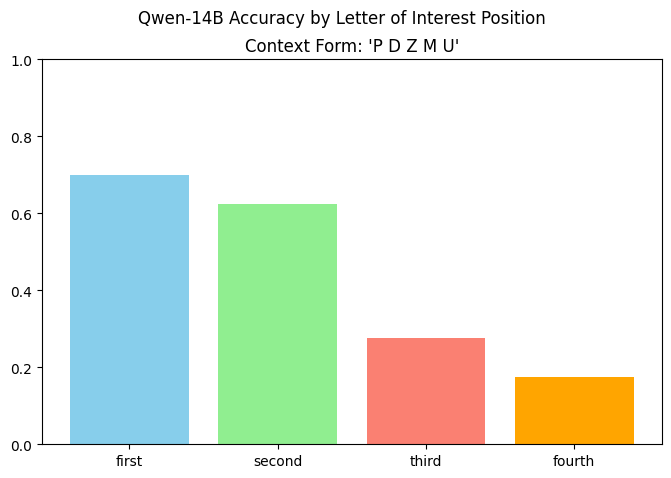

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.suptitle('Qwen-14B Accuracy by Letter of Interest Position')
plt.title("Context Form: 'P D Z M U'")
plt.ylim(0, 1)
plt.bar(
    x=["first", "second", "third", "fourth"],
    height=group_accuracies.values(),
    color=["skyblue", "lightgreen", "salmon", "orange"],
)

In [20]:
correct_count / total_count

0.7

In [ ]:
accuracy_dict = {
    "first": 0.7,
    "second": 0.325,
    "third": 0.024,
    "fourth": 0.119,
}

In [3]:
article_first = [
    ['An artist Jane paints daily', 'The artist Jane paints daily'],
    ['The pet fish swims quickly', 'A pet fish swims quickly'],
    ['An animal fish swims well', 'The animal fish swims well'],
    ['A friend Tom visits often', 'The friend Tom visits often'],
    ['The woman Mary cooks well', 'A woman Mary cooks well'],
    ['A machine cars need fuel', 'The machine cars need fuel'],
    ['An invention cars changed society', 'The invention cars changed society'],
    ['A plant trees loves sun', 'The plant trees loves sun'],
    ['The happy dog is loud', 'A happy dog is loud'],
    ['A gentle breeze blows softly', 'The gentle breeze blows softly'],
    ['The small mouse runs away', 'A small mouse runs away'],
    ['A young child plays happily', 'The young child plays happily'],
    ['An old clock ticks slowly', 'The old clock ticks slowly'],
    ['A new book smells fresh', 'The new book smells fresh'],
    ['The quiet library stays peaceful', 'A quiet library stays peaceful'],
    ['A busy street sounds noisy', 'The busy street sounds noisy'],
    ['The fast train arrives soon', 'A fast train arrives soon'],
    ['A sharp knife cuts easily', 'The sharp knife cuts easily'],
    ['A nice flower smells sweet', 'The nice flower smells sweet'],
    ['A thin wire bends easily', 'The thin wire bends easily'],
]

article_second = [
    ["Jack the boy runs fast", "Jack a boy runs fast"],
    ["Jack a student likes math", "Jack the student likes math"],
    ["Jack an actor plays well", "Jack the actor plays well"],
    ["Jane the girl sings beautifully", "Jane a girl sings beautifully"],
    ["Jane a teacher helps kids", "Jane the teacher helps kids"],
    ["Jane an artist paints daily", "Jane the artist paints daily"],
    ["Fish the pet swims quickly", "Fish a pet swims quickly"],
    ["Fish a creature needs water", "Fish the creature needs water"],
    ["Fish an animal that swims", "Fish the animal that swims"],
    ["Tom the man works hard", "Tom a man works hard"],
    ["Tom a friend visits often", "Tom the friend visits often"],
    ["Tom an employee arrives early", "Tom the employee arrives early"],
    ["Kate the woman cooks well", "Kate a woman cooks well"],
    ["Kate a nurse helps patients", "Kate the nurse helps patients"],
    ["Kate an author writes books", "Kate the author writes books"],
    ["Cars the vehicles move fast", "Cars a vehicles move fast"],
    ["Cars a machine need fuel", "Cars the machine need fuel"],
    ["Cars an invention changed society", "Cars the invention changed society"],
    ["Trees the roots grow deep", "Trees a roots grow deep"],
    ["Trees a sun loving plant", "Trees the sun loving plant"],
    ["Trees an oxygen making organism", "Trees the oxygen making organism"],
    ["Bob the builder works daily", "Bob a builder works daily"],
    ["Bob a farmer grows corn", "Bob the farmer grows corn"],
    ["Bob an engineer designs bridges", "Bob the engineer designs bridges"],
    ["Mary the doctor heals people", "Mary a doctor heals people"],
    ["Mary a lawyer fights cases", "Mary the lawyer fights cases"],
    ["Mary an athlete runs races", "Mary the athlete runs races"],
    ["Mike the chef cooks pasta", "Mike a chef cooks pasta"],
    ["Mike a pilot flies planes", "Mike the pilot flies planes"],
    ["Mike an artist shapes clay", "Mike the artist shapes clay"],
    ["Lisa the singer performs nightly", "Lisa a singer performs nightly"],
    ["Lisa a dancer moves gracefully", "Lisa the dancer moves gracefully"],
    ["Lisa an actress plays roles", "Lisa the actress plays roles"],
    ["Books the items contain knowledge", "Books a items contain knowledge"],
    ["Books a product sells quickly", "Books the product sells quickly"],
    ["Books an object fills shelves", "Books the object fills shelves"],
    ["Phones the devices ring constantly", "Phones a devices ring constantly"],
    ["Phones a gadget needs charging", "Phones the gadget needs charging"],
    ["Phones an invention connects people", "Phones the invention connects people"],
    ["Wind the force moves leaves", "Wind a force moves leaves"],
    ["Wind an element shaking trees", "Wind the element shaking trees"],
    ["Wind an energy powers mills", "Wind the energy powers mills"],
]

article_third = [
    ["Jack is the best boy", "Jack is a best boy"],
    ["Jack is a good boy", "Jack is the good boy"],
    ["Jack is an awesome boy", "Jack is the awesome boy"],
    ["Jane is the best girl", "Jane is a best girl"],
    ["Jane is a good girl", "Jane is the good girl"],
    ["Jane is an awesome girl", "Jane is the awesome girl"],
    ["Fish are the best pets", "Fish are a best pets"],
    ["Fish make a good pet", "Fish make the good pet"],
    ["Fish are an awesome pet", "Fish are the awesome pet"],
    ["Tom is the tallest man", "Tom is a tallest man"],
    ["Tom is a smart guy", "Tom is the smart guy"],
    ["Tom is an old friend", "Tom is the old friend"],
    ["Mary is the best lady", "Mary is a best lady"],
    ["Mary is a kind woman", "Mary is the kind woman"],
    ["Mary is an early bird", "Mary is the early bird"],
    ["Cars are the fastest machines", "Cars are a fastest machines"],
    ["Cars need a new engine", "Cars need the new engine"],
    ["Cars get an oil change", "Cars get the oil change"],
    ["Trees give the best shade", "Trees give a best shade"],
    ["Trees need a good forest", "Trees need the good forest"],
    ["Trees grow an inch yearly", "Trees grow the inch yearly"],
]

article_fourth = [
    ["Jack gives me the ball", "Jack gives me a ball"],
    ["Jack shows me a trick", "Jack shows me the trick"],
    ["Jack tells me an idea", "Jack tells me the idea"],
    ["Jane brings me the book", "Jane brings me a book"],
    ["Jane sends me a letter", "Jane sends me the letter"],
    ["Jane gives me an apple", "Jane gives me the apple"],
    ["Fish make me the happiest", "Fish make me a happiest"],
    ["Fish give me a smile", "Fish give me the smile"],
    ["Fish bring me an escape", "Fish bring me the escape"],
    ["Tom lends me the money", "Tom lends me a money"],
    ["Tom buys me a gift", "Tom buys me the gift"],
    ["Tom owes me an answer", "Tom owes me the answer"],
    ["Mary baked me the cake", "Mary baked me a cake"],
    ["Mary draws me a picture", "Mary draws me the picture"],
    ["Mary sings me an anthem", "Mary sings me the anthem"],
    ["Cars cost me the most", "Cars cost me a most"],
    ["Cars save me a walk", "Cars save me the walk"],
    ["Cars offer me an option", "Cars offer me the option"],
    ["Trees give me the oxygen", "Trees give me an oxygen"],
    ["Trees offer me a refuge", "Trees offer me the refuge"],
    ["Trees provide me an escape", "Trees provide me the escape"],
]

In [27]:
article_first_clean = []
for sentence_pair in article_first:
    clean_sentence_pair = []
    for sentence in sentence_pair:
        sentence_tokenized = tokenizer.encode(sentence)
        if len(sentence_tokenized) != 5:
            for token in sentence_tokenized:
                print(tokenizer.decode(token))
        else:
            clean_sentence_pair.append(sentence)
    article_first_clean.append(clean_sentence_pair)
assert article_first_clean == article_first

In [28]:
PROMPT_TEMPLATE = "{}. Q: What is the {} word in the previous sentence? Answer in one word only! A:"
OPTIONS = ["first", "second", "third", "fourth"]

## Get Basline Accuracy

In [ ]:
import torch
import time

correct_count = 0
total_count = 0

OPTION_INDEX = 0  # Change this index to select different word positions (0 for first, 1 for first, etc.)

valid_sentences = []

for sentence_pair in article_first[:20]:
    valid_sentence_pair = []
    for sentence in sentence_pair:
        # Get the model's prediction for the next token
        prompt = PROMPT_TEMPLATE.format(sentence, OPTIONS[OPTION_INDEX])
        input_ids = model.tokenizer.encode(prompt)
        with model.trace(prompt):
            logits = model.output.logits.save()
        predicted_token_id = logits[0, -1].argmax().item()
        predicted_token = model.tokenizer.decode([predicted_token_id])
        print(f"Prompt: {prompt}")
        print(f"Predicted token: {predicted_token}")
        print(f"Correct answer: {sentence.split()[OPTION_INDEX]}")
        print("-----")
        if predicted_token.strip().lower() == sentence.split()[OPTION_INDEX].lower():
            correct_count += 1
            # Add to valid sentences if correct
            valid_sentence_pair.append(sentence)
        total_count += 1
    valid_sentences.append(valid_sentence_pair)

Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [19]:
valid_sentences

[['Jack the boy runs fast'],
 ['Jack the student likes math'],
 ['Jack the actor plays well'],
 ['Jane the girl sings beautifully'],
 ['Jane the teacher helps kids'],
 ['Jane the artist paints daily'],
 ['Fish the pet swims quickly'],
 ['Fish the creature needs water'],
 ['Fish the animal that swims'],
 [],
 [],
 [],
 [],
 ['Kate the nurse helps patients'],
 ['Kate the author writes books'],
 [],
 [],
 [],
 ['Trees the roots grow deep'],
 ['Trees the sun loving plant']]

In [20]:
correct_count / total_count

0.325

In [19]:
accuracy_dict = {
    "first": 0.693,
    "second": 0.325,
    "third": 0.024,
    "fourth": 0.119,
}

<BarContainer object of 4 artists>

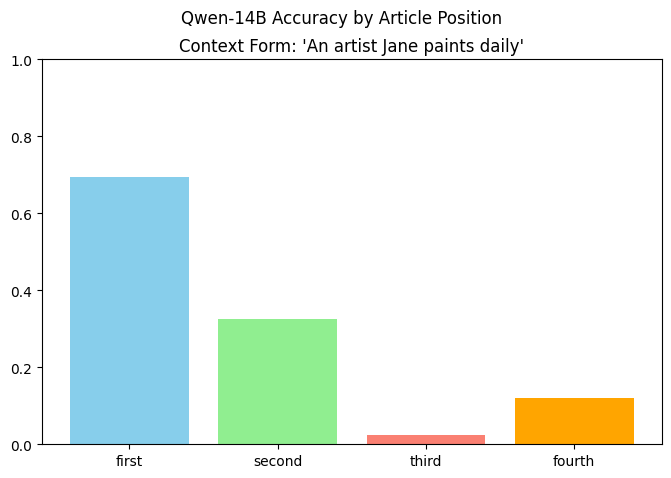

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.suptitle('Qwen-14B Accuracy by Article Position')
plt.title("Context Form: 'An artist Jane paints daily'")
plt.ylim(0, 1)
plt.bar(
    accuracy_dict.keys(),
    accuracy_dict.values(),
    color=["skyblue", "lightgreen", "salmon", "orange"],
)

# Run Activation Patching

In [104]:
clean_prompt = PROMPT_TEMPLATE.format(article_first[0][0], "first")
print(clean_prompt)
patch_prompt = PROMPT_TEMPLATE.format(article_first[0][1], "first")
print(patch_prompt)

The boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:
A boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:


In [105]:
clean_target_token_id = tokenizer.encode(clean_prompt, add_special_tokens=False)[0]
print(clean_target_token_id)
patch_target_token_id = tokenizer.encode(patch_prompt, add_special_tokens=False)[0]
print(patch_target_token_id)

791
32


In [106]:
import os
os.chdir('/share/u/gio/mechinterp/')

In [107]:
clean_activations = []
with model.trace(clean_prompt):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    logits = model.output.logits.save()
    clean_target_logits = model.output.logits[0, -1, clean_target_token_id].item().save()

clean_prediction = logits.argmax(dim=-1)[0, -1]
clean_token_prediction = model.tokenizer.decode(clean_prediction)
print(len(clean_activations), clean_token_prediction, clean_target_logits)

32  The 12.856864929199219


In [108]:
patch_prompt

'A boy Jack runs fast. Q: What is the first word in the previous sentence? Answer in one word only. A:'

In [109]:
with model.trace(patch_prompt):
    logits = model.output.logits.save()
    clean_target_logits_corrupt = model.output.logits[0, -1, clean_target_token_id].item().save()

corrupt_target_logits = logits[0, -1, patch_target_token_id].item()
corrupt_prediction = logits.argmax(dim=-1)[0, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)
print(corrupt_target_logits, corrupt_token_prediction, clean_target_logits_corrupt)

10.440034866333008  The 12.285228729248047


In [93]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

Baseline logit difference (clean - corrupt): 3.975156784057617


In [94]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(patch_prompt)

In [ ]:
from tqdm import trange

patched_activations = []
